# Sales & Demand Forecasting for Businesses

## Objective
Build a machine learning model to forecast future sales using historical business data.bold text

In [2]:
import pandas as pd

df = pd.read_csv("SuperStore.csv", encoding='latin1')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Cleaning

In this step, we check for missing values and clean the dataset.

In [3]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [5]:
df.dropna(inplace=True)

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

## Feature Engineering

Creating Year, Month, and Day features from the Order Date column.

In [7]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Day'] = df['Order Date'].dt.day

## Monthly Sales Aggregation

Grouping sales data by month to analyze trends over time.

In [9]:
monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='ME')
)['Sales'].sum().reset_index()

## Forecasting Model

Using Linear Regression to forecast future sales.

In [11]:
from sklearn.linear_model import LinearRegression

monthly_sales['Month_Number'] = range(len(monthly_sales))

X = monthly_sales[['Month_Number']]
y = monthly_sales['Sales']

model = LinearRegression()
model.fit(X,y)

LinearRegression()

## Sales Trend Visualization

Visualizing historical monthly sales trends.

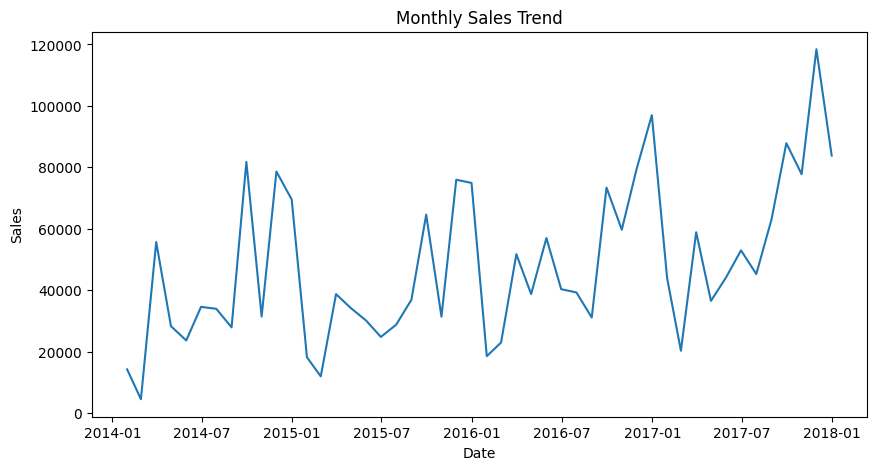

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Order Date'],
         monthly_sales['Sales'])

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [12]:
future_months = 12

future_X = pd.DataFrame({
    'Month_Number':
    range(len(monthly_sales),
          len(monthly_sales)+future_months)
})

forecast = model.predict(future_X)

## Model Evaluation

Evaluating forecasting performance using Mean Absolute Error (MAE).



In [14]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X)

mae = mean_absolute_error(y,predictions)

print("MAE:",mae)

MAE: 17457.725724823373


## Future Sales Forecast

Comparing historical sales with predicted future sales.

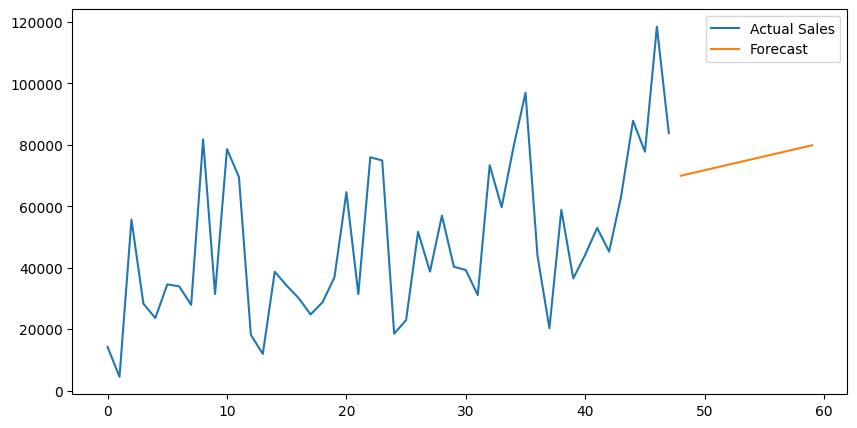

In [13]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales['Month_Number'],
         monthly_sales['Sales'],
         label='Actual Sales')

plt.plot(future_X['Month_Number'],
         forecast,
         label='Forecast')

plt.legend()
plt.show()

In [15]:
plt.savefig("sales_trend.png")

<Figure size 640x480 with 0 Axes>

In [16]:
plt.savefig("forecast.png")

<Figure size 640x480 with 0 Axes>

## Business Insights

The sales forecast predicts future sales trends based on historical data.

Benefits for businesses:

- Better inventory planning
- Improved staffing decisions
- Better budgeting and financial planning
- Reduced risk of overstocking
- Improved demand forecasting

This forecast helps managers make informed business decisions for future growth.